In [1]:
# Install required library
!pip install sentence-transformers seaborn matplotlib

In [2]:
# Imports
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker",
    "The team won the match by chasing the target",
    "Fielders saved crucial runs in the last over",

    # Cooking (3)
    "Add spices and cook the vegetables thoroughly",
    "The recipe requires baking at 180 degrees",
    "Chop onions and sauté them in oil",

    # Cybersecurity (3)
    "Use strong passwords to protect your accounts",
    "Firewalls help prevent unauthorized access",
    "Encryption ensures data privacy and security"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
similarity_matrix = cosine_similarity(embeddings)

print("Shape of matrix:", similarity_matrix.shape)

Shape of matrix: (10, 10)


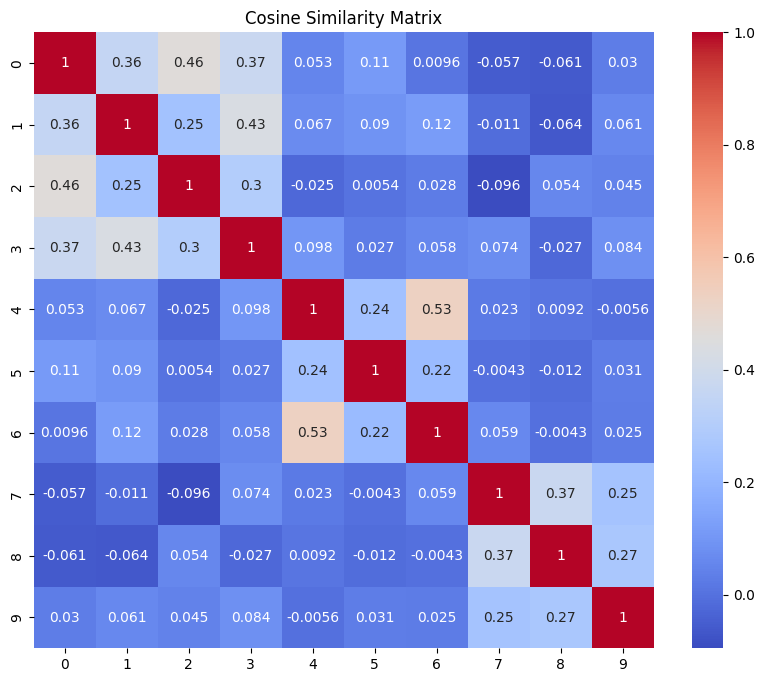

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [8]:
top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

Sentence: The bowler delivered a perfect yorker
Similarity Score: 0.5481

